In [29]:
# from google.colab import drive
# drive.mount('/content/drive')

In [30]:
# import sys
# import os
# # path = "/content/drive/MyDrive/Colab Notebooks/rf_cnn"
# path = "~/Documents/pj_cnn"
# os.chdir(path)
# sys.path.append(path)

In [31]:
# @title
# !unzip "data.zip" -d "."

In [32]:
# !ls

In [33]:
!pip install -r "requirements.txt"

ERROR: Could not find a version that satisfies the requirement csv (from versions: none)
ERROR: No matching distribution found for csv


In [34]:
from data.rf_dataset import get_dataloaders
from models.cnn_model import RFNet
from train.train import train_one_epoch, validation, save_checkpoint, load_checkpoint
from utils.check_dataset import check_dataset, download_dataset
from utils.visualize import plot_loss, plot_distribution_of_dataset, plot_confusion_matrix, create_visualization_figure, plot_accuracy
from config.config import *
import matplotlib.pyplot as plt
import numpy as np
import torch
import csv
import os


In [35]:
# @title
def check_device():
    is_cuda = torch.cuda.is_available()
    if is_cuda:
        print(f"- Sử dụng GPU: {torch.cuda.get_device_name(0)}")
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
        print("- Sử dụng CPU")
    return device

def get_version(path):
    if not os.path.exists(path):
        os.makedirs(path)
    versions = [d for d in os.listdir(path) if d.startswith("ver")]
    ver = len(versions) + 1
    return f"ver{ver}"

def save_loss_acc(header, row, path):
    header = np.array(header).flatten()
    row = np.array(row).flatten()
    csv_path = os.path.join(path, "train_log.csv")
    file_exists = os.path.isfile(csv_path)

    with open(csv_path, mode='a', newline='') as f:
        writer = csv.writer(f)

        if not file_exists:
            writer.writerow(header)

        writer.writerow(row)


In [36]:

def main(resume=False, checkpoint_path=None):
    # prepare
    if checkpoint_path is None:
      checkpoint_path = os.path.join(CHECKPOINT_DIR, get_version(CHECKPOINT_DIR))
      os.mkdir(checkpoint_path)
      print(f"- Lượt huấn luyện mới lưu tại: {checkpoint_path}")
    download_dataset(DATASET_PATH, KAGGLE_PATH)
    check_dataset(DATASET_PATH)
    device = check_device()
    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True


    # dataset
    train_loader, val_loader = get_dataloaders(DATASET_PATH, BATCH_SIZE, device, NUM_WORKERS, TRAIN_SPLIT, SEED)

    # visualize distribution of dataset
    fig, ax = create_visualization_figure(row=1, col=2, figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plot_distribution_of_dataset(train_loader.dataset, ax[0], "Train")
    plt.subplot(1, 2, 2)
    plot_distribution_of_dataset(val_loader.dataset, ax[1], "Validation")
    plt.show()

    # model
    model = RFNet(num_classes=NUM_CLASSES)
    model.to(device)

    # loss với label smoothing
    criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

    # optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2, # giảm lr nếu val loss không cải thiện sau 2 epochs
        min_lr=1e-6
    )

    # Kiểm tra tổng parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"- Tổng tham số: {total_params}")

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_acc = 0.0

    start_epoch = 0
    if resume:
        start_epoch, train_losses, val_losses, train_accs, val_accs = load_checkpoint(
            model,
            optimizer,
            f"{checkpoint_path}/last_checkpoint.pth",
            device
        )
        print(f"- Đã load checkpoint từ {checkpoint_path}: epoch {start_epoch+1}")

    for epoch in range(start_epoch, EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )
        val_loss, val_acc = validation(
            model,
            val_loader,
            criterion,
            device
        )

        # lưu loss và acc để vẽ biểu đồ
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Lưu log
        save_loss_acc(
            ["epoch", "train_loss", "val_loss", "train_acc", "val_acc", "lr"],
            [epoch+1, train_loss, val_loss, train_acc, val_acc, optimizer.param_groups[0]["lr"]], 
             checkpoint_path
        )

        # cập nhật learning rate dựa trên val loss
        scheduler.step(val_loss)
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
        print("LR: ", optimizer.param_groups[0]["lr"])

    
        save_checkpoint(
            epoch + 1,
            model,
            optimizer,
            train_losses,
            val_losses,
            train_accs,
            val_accs,
            f"{checkpoint_path}/last_checkpoint.pth"
        )
        if (epoch + 1) % SAVE_EVERY == 0:

            save_checkpoint(
                epoch + 1,
                model,
                optimizer,
                train_losses,
                val_losses,
                train_accs,
                val_accs,
                f"{checkpoint_path}/checkpoint_epoch_{epoch+1}.pth"
            )
        print("- Đã lưu check_point")

        # save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{checkpoint_path}/{MODEL_NAME}")
            print(f"- Model saved with val acc: {best_acc:.4f}")

    fig, ax = create_visualization_figure(row=1, col=2, figsize=(12, 5))
    plot_loss(train_losses, val_losses, ax[0])
    plot_accuracy(train_accs, val_accs, ax[1])

- Lượt huấn luyện mới lưu tại: checkpoints\ver1
- Dataset đã tồn tại, không cần tải lại.
- Số lượng lớp đầu ra: 12
	0: "16-QAM"		-> 6400 ảnh
	1: "B-FM"		-> 6400 ảnh
	2: "Barker"		-> 6400 ảnh
	3: "BPSK"		-> 6400 ảnh
	4: "CPFSK"		-> 6400 ảnh
	5: "DSB-AM"		-> 6400 ảnh
	6: "GFSK"		-> 6400 ảnh
	7: "LFM"		-> 6400 ảnh
	8: "PAM4"		-> 6400 ảnh
	9: "QPSK"		-> 6400 ảnh
	10: "Rect"		-> 6400 ảnh
	11: "StepFM"		-> 6400 ảnh
- Tổng số ảnh trong dataset: 76800
- Kích thước ảnh mẫu:  (224, 224)
- Sử dụng GPU: NVIDIA GeForce RTX 4060 Laptop GPU


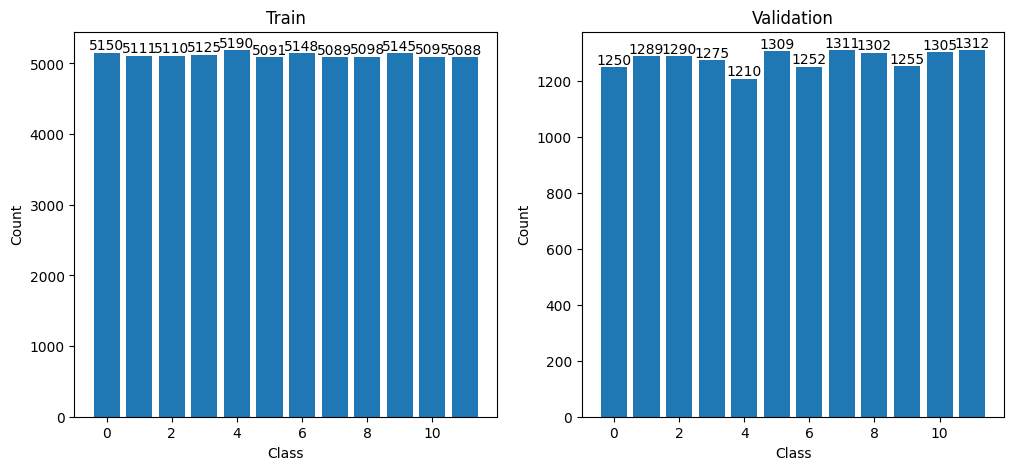

- Tổng tham số: 63052

Epoch 1/20


100%|██████████| 480/480 [00:15<00:00, 31.58it/s]


Train Loss: 1.6804 | Train Acc: 0.4632
Val   Loss: 1.3454 | Val   Acc: 0.6238
LR:  0.001
- Đã lưu check_point
- Model saved with val acc: 0.6238

Epoch 2/20


100%|██████████| 480/480 [00:14<00:00, 32.48it/s]


Train Loss: 1.3384 | Train Acc: 0.6287
Val   Loss: 1.1996 | Val   Acc: 0.7063
LR:  0.001
- Đã lưu check_point
- Model saved with val acc: 0.7063

Epoch 3/20


...

Train Loss: 0.9783 | Train Acc: 0.8295
Val   Loss: 0.9061 | Val   Acc: 0.8434
LR:  0.001
- Đã lưu check_point

Epoch 19/20


100%|██████████| 480/480 [00:14<00:00, 33.59it/s]


Train Loss: 0.9745 | Train Acc: 0.8310
Val   Loss: 0.9452 | Val   Acc: 0.8072
LR:  0.001
- Đã lưu check_point

Epoch 20/20


100%|██████████| 480/480 [00:14<00:00, 33.27it/s]


Train Loss: 0.9724 | Train Acc: 0.8333
Val   Loss: 0.8855 | Val   Acc: 0.8463
LR:  0.0005
- Đã lưu check_point


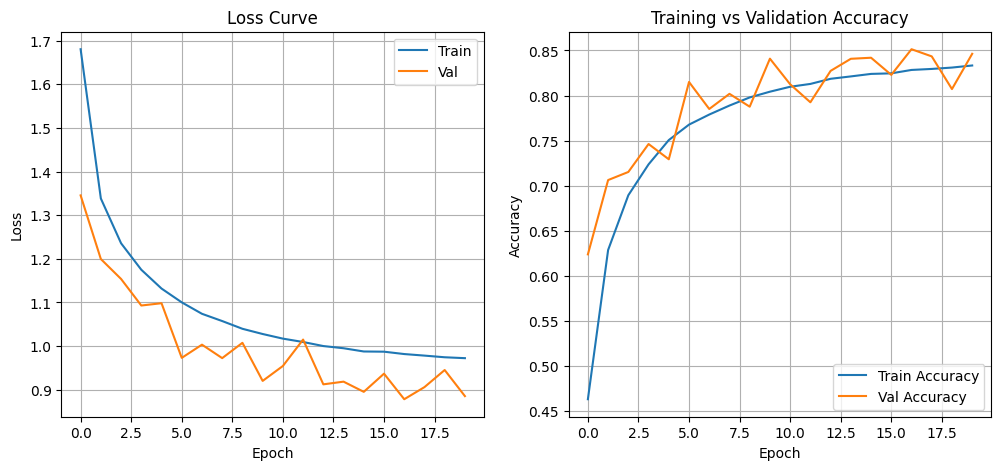

In [37]:
if __name__ == "__main__":
    # main(resume=True, checkpoint_path="checkpoints/ver3")
    main()
